# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [2]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [3]:
filename="SUSY-small.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [7]:
!pip install scikit-learn --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [17]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [27]:
N_Train=400000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]
# 3. Re-train the Fisher model with the valid split
Fisher.fit(X_Train, y_Train)
Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [28]:
Fisher.fit(X_Train,y_Train)
len(df)

500000

We can plot the output, comparing signal and background:

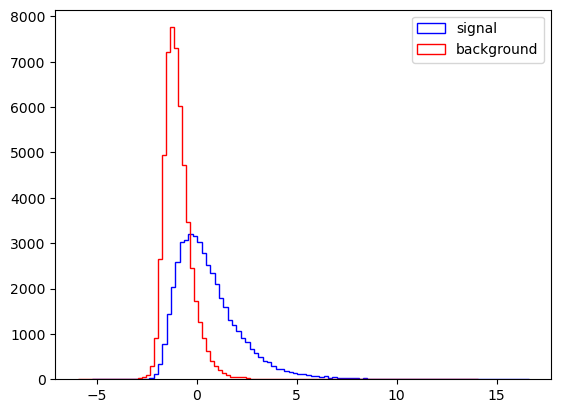

In [29]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

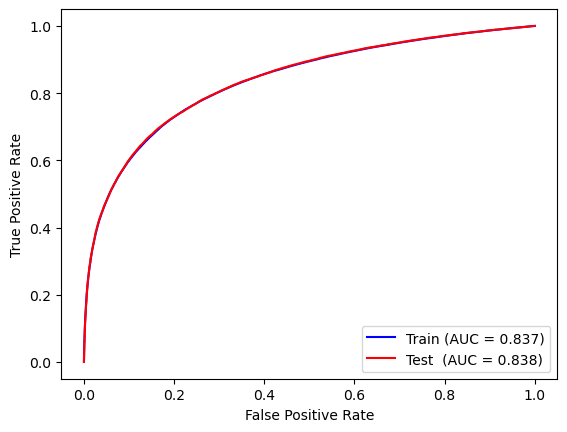

In [32]:
# Computing ROC for both training and test using the trained Fisher
from sklearn.metrics import roc_curve, auc

#getting decision scores on train and test sets
train_scores = Fisher.decision_function(X_Train)
test_scores  = Fisher.decision_function(X_Test)

#computing FPR, TPR for each
fpr_train, tpr_train, _ = roc_curve(y_Train, train_scores)
fpr_test,  tpr_test,  _ = roc_curve(y_Test,  test_scores)

#computing AUCs to put on the legend
auc_train = auc(fpr_train, tpr_train)
auc_test  = auc(fpr_test,  tpr_test)

#overlaying both ROC curves on a single plot
plt.figure()
plt.plot(fpr_train, tpr_train, color="blue", label="Train (AUC = %0.3f)" % auc_train)
plt.plot(fpr_test,  tpr_test,  color="red",  label="Test  (AUC = %0.3f)" % auc_test)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

#The two curves sit almost on top of each other, so there's no real sign of overfitting/bias here.
#LDA is a simple linear model and 4M training events is plenty, so train and test performance line up.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

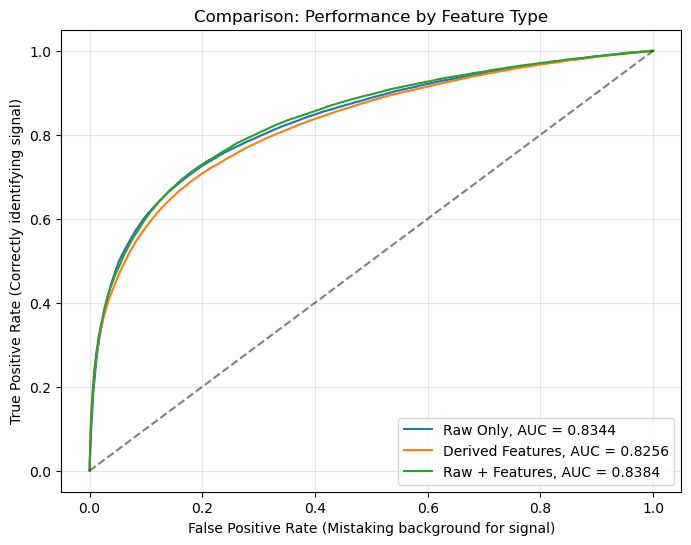

In [33]:
# 1. ORGANIZE THE INPUT COLUMNS
# 'RawNames' are basic measurements (momentum, angles, energy)
RawNames = ["l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]

# 'FeatureNames' are derived physics variables (e.g., M_R, MT2) 
# We find these by taking all variables and removing the 'Raw' ones
FeatureNames = list(set(VarNames[1:]).difference(RawNames))

# 2. CREATE THREE DIFFERENT TRAINING/TESTING SETS
# Set A: Only raw data
X_Train_raw = Train_Sample[RawNames]
X_Test_raw  = Test_Sample[RawNames]

# Set B: Only high-level derived features
X_Train_feat = Train_Sample[FeatureNames]
X_Test_feat  = Test_Sample[FeatureNames]

# Set C: All data combined (Raw + Features)
X_Train_all = Train_Sample[VarNames[1:]]
X_Test_all  = Test_Sample[VarNames[1:]]

# 3. INITIALIZE AND TRAIN THREE SEPARATE MODELS
# We train one Fisher Discriminant for each group to see which group is "smarter"
Fisher_raw = DA.LinearDiscriminantAnalysis()
Fisher_raw.fit(X_Train_raw, y_Train)

Fisher_feat = DA.LinearDiscriminantAnalysis()
Fisher_feat.fit(X_Train_feat, y_Train)

Fisher_all = DA.LinearDiscriminantAnalysis()
Fisher_all.fit(X_Train_all, y_Train)

# 4. CALCULATE PERFORMANCE (ROC CURVES)
# We test how well each model performs on the 'unseen' Test data
# 'decision_function' gives a probability score for each event
fpr_raw,  tpr_raw,  _ = roc_curve(y_Test, Fisher_raw.decision_function(X_Test_raw))
fpr_feat, tpr_feat, _ = roc_curve(y_Test, Fisher_feat.decision_function(X_Test_feat))
fpr_all,  tpr_all,  _ = roc_curve(y_Test, Fisher_all.decision_function(X_Test_all))

# 5. CALCULATE AUC (Area Under the Curve)
# AUC is a single number from 0.5 (random guessing) to 1.0 (perfect prediction)
auc_raw  = auc(fpr_raw,  tpr_raw)
auc_feat = auc(fpr_feat, tpr_feat)
auc_all  = auc(fpr_all,  tpr_all) 

# 6. VISUALIZE THE COMPARISON
plt.figure(figsize=(8, 6))

# Plot the curves - the higher the curve (closer to top-left), the better the model
plt.plot(fpr_raw,  tpr_raw,  label="Raw Only, AUC = %1.4f" % auc_raw)
plt.plot(fpr_feat, tpr_feat, label="Derived Features, AUC = %1.4f" % auc_feat)
plt.plot(fpr_all,  tpr_all,  label="Raw + Features, AUC = %1.4f" % auc_all)

# Add a diagonal dashed line representing a random 50/50 guess
plt.plot([0,1], [0,1], "k--", alpha=0.5)

# Formatting the chart
plt.xlabel("False Positive Rate (Mistaking background for signal)")
plt.ylabel("True Positive Rate (Correctly identifying signal)")
plt.title("Comparison: Performance by Feature Type")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 6.

In [35]:
#part a
# Choosing 3 models to compare with our Fisher (LDA) results:
#   1. Logistic Regression: A linear model often used to verify LDA performance.
#   2. Decision Tree: A fast model that uses a flow-chart style to find patterns.
#   3. Random Forest: A group of many trees working together for better accuracy.

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

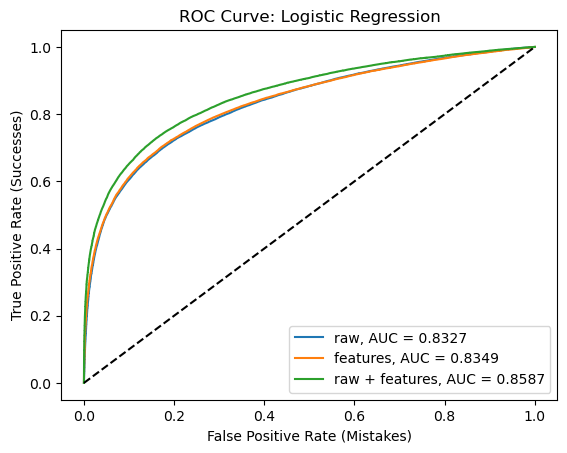

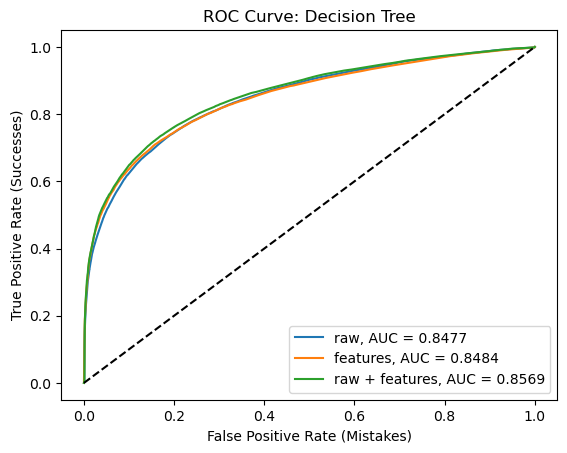

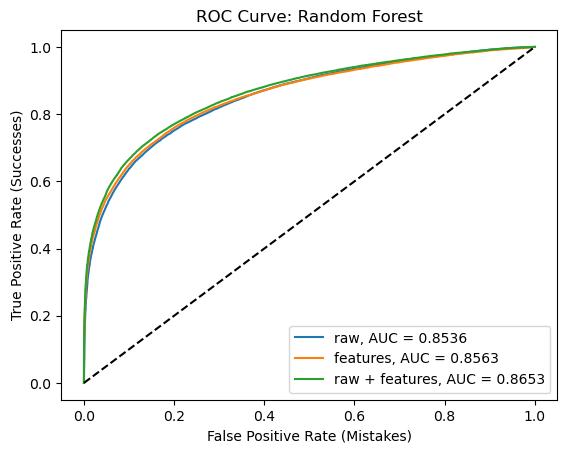

In [36]:
#part b
#creating a "helper function" to save time. 
# This function takes any ML model and tests it 3 times: 
# using only raw data, only physics features, and then both.
def compare_inputs(clf_class, clf_kwargs={}, title=""):
    
    # Create three empty versions of the same model (e.g., three empty Decision Trees)
    clf_raw  = clf_class(**clf_kwargs)
    clf_feat = clf_class(**clf_kwargs)
    clf_all  = clf_class(**clf_kwargs)

    # Train each model on its specific group of data
    clf_raw.fit(X_Train_raw,   y_Train)  # Training on basic sensor data
    clf_feat.fit(X_Train_feat, y_Train) # Training on physics-calculated variables
    clf_all.fit(X_Train_all,   y_Train)  # Training on everything combined

    # This inner function helps get the "confidence score" for each prediction.
    # Different models use different names for this (decision_function or predict_proba).
    def get_scores(clf, X):
        if hasattr(clf, "decision_function"):
            return clf.decision_function(X) # Used by models like Logistic Regression
        else:
            return clf.predict_proba(X)[:, 1] # Used by models like Random Forest

    #test the models!compare their predictions against the real "signal" labels.
    # fpr = False Positive Rate, tpr = True Positive Rate
    fpr_raw,  tpr_raw,  _ = roc_curve(y_Test, get_scores(clf_raw,  X_Test_raw))
    fpr_feat, tpr_feat, _ = roc_curve(y_Test, get_scores(clf_feat, X_Test_feat))
    fpr_all,  tpr_all,  _ = roc_curve(y_Test, get_scores(clf_all,  X_Test_all))

    # Calculate the AUC (Area Under Curve). 
    # Closer to 1.000 means the model is better at separating signal from noise.
    auc_raw  = auc(fpr_raw,  tpr_raw)
    auc_feat = auc(fpr_feat, tpr_feat) 
    auc_all  = auc(fpr_all,  tpr_all)

    # Draw the ROC plot so can visually see which data group performed best
    plt.figure()
    plt.plot(fpr_raw,  tpr_raw,  label="raw, AUC = %1.4f" % auc_raw)
    plt.plot(fpr_feat, tpr_feat, label="features, AUC = %1.4f" % auc_feat)
    plt.plot(fpr_all,  tpr_all,  label="raw + features, AUC = %1.4f" % auc_all)
    
    # Add a diagonal line (this represents what a random guess would look like)
    plt.plot([0,1], [0,1], "k--")
    plt.xlabel("False Positive Rate (Mistakes)")
    plt.ylabel("True Positive Rate (Successes)")
    plt.title("ROC Curve: " + title)
    plt.legend(loc="lower right")
    plt.show()

    # Save the trained models and their scores 
    return {"raw": clf_raw, "feat": clf_feat, "all": clf_all,
            "auc_raw": auc_raw, "auc_feat": auc_feat, "auc_all": auc_all}



# Run Logistic Regression: A standard model that looks for linear patterns.
#set max_iter=1000 to give it enough time to find the best answer.
results_lr = compare_inputs(LogisticRegression, 
                            {"max_iter": 1000}, 
                            title="Logistic Regression")

# Run Decision Tree: A model that makes a Yes/No flow-chart.
#limit depth to 10 so it doesn't get too complicated and "overfit."
results_dt = compare_inputs(DecisionTreeClassifier, 
                            {"max_depth": 10, "random_state": 0}, 
                            title="Decision Tree")

# Run Random Forest: An advanced model that uses 20 different trees at once.
# "n_jobs=-1" tells the computer to use all its processor cores to finish faster.
results_rf = compare_inputs(RandomForestClassifier, 
                            {"n_estimators": 20, "max_depth": 10, "random_state": 0, "n_jobs": -1}, 
                            title="Random Forest")

In [37]:
#part c
#identifying the top-performing model from previous results
#selecting the Random Forest classifier trained on all features
best_clf = results_rf["all"]
X_Test_best = X_Test_all

#Extracting model confidence scores for the test data
#using decision_function for linear models or predict_proba for tree models
if hasattr(best_clf, "decision_function"):
    scores_test = best_clf.decision_function(X_Test_best)
else:
    #Column 1 represents the probability of the event being 'signal'
    scores_test = best_clf.predict_proba(X_Test_best)[:, 1]

#Filtering scores by their ground truth labels
#creating separate arrays for true signal and true background scores
F_sig = scores_test[y_Test == 1]
F_bkg = scores_test[y_Test == 0]

#defining experimental physics scenarios
#formating(Number of expected Signals, Number of expected Backgrounds)
scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)]

#initializing threshold scan range
#creating 200 evenly spaced cutoff points between the min and max scores
F_all = np.concatenate([F_sig, F_bkg])
thresholds = np.linspace(F_all.min(), F_all.max(), 200)

#looping through each scenario to find the maximum discovery potential
for N_S, N_B in scenarios:
    best_sigma = -np.inf
    best_threshold = None
    best_eps_s = None
    best_eps_b = None

    #evualating performance for every threshold in the scan
    for t in thresholds:

        # Calculate efficiency: percentage of data surviving the cutoff 't'
        eps_s = np.sum(F_sig > t) / float(len(F_sig))
        eps_b = np.sum(F_bkg > t) / float(len(F_bkg))

        # Scale efficiencies by the expected number of events in the scenario
        N_S_prime = eps_s * N_S
        N_B_prime = eps_b * N_B

        # Calculate Significance (Signal / sqrt(Total Events))
        # This determines the statistical strength of the discovery
        if N_S_prime + N_B_prime > 0:
            sigma = N_S_prime / np.sqrt(N_S_prime + N_B_prime)
        else:
            sigma = 0

        # Update and store values if current significance is the highest found
        if sigma > best_sigma:
            best_sigma = sigma
            best_threshold = t
            best_eps_s = eps_s
            best_eps_b = eps_b

    # Output optimal parameters for the current scenario
    print("Scenario:", (N_S, N_B))
    print("Best threshold:", round(best_threshold, 4))
    print("epsilon_S:", round(best_eps_s, 4))
    print("epsilon_B:", round(best_eps_b, 4))
    print("Max significance:", round(best_sigma, 4))
    print()

Scenario: (10, 100)
Best threshold: 0.7889
epsilon_S: 0.4539
epsilon_B: 0.0203
Max significance: 1.7705

Scenario: (100, 1000)
Best threshold: 0.7889
epsilon_S: 0.4539
epsilon_B: 0.0203
Max significance: 5.5988

Scenario: (1000, 10000)
Best threshold: 0.7889
epsilon_S: 0.4539
epsilon_B: 0.0203
Max significance: 17.7049

Scenario: (10000, 100000)
Best threshold: 0.7889
epsilon_S: 0.4539
epsilon_B: 0.0203
Max significance: 55.9878



### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

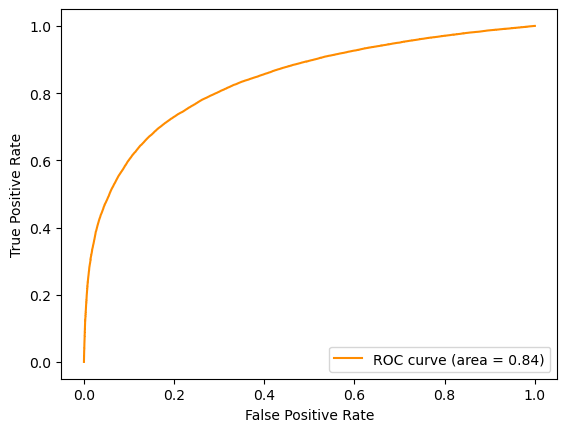

In [38]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [39]:
#Load necessary evaluation tools from sklearn
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score

#Calculate the overall ROC curve and Area Under the Curve (AUC)
# This represents the general power of the model before applying any specific threshold
fpr_full, tpr_full, _ = roc_curve(y_Test, scores_test)
roc_auc_full = auc(fpr_full, tpr_full)

#Create a container for the final results
table_rows = []

#Process each scenario individually
for N_S, N_B in scenarios:

    #Reset variables to find the best settings for the current scenario
    best_sigma = -np.inf
    best_threshold = None
    best_eps_s = None
    best_eps_b = None

    #Scan thresholds to maximize significance (Signal / sqrt(Total))
    for t in thresholds:
        eps_s = np.sum(F_sig > t) / float(len(F_sig))
        eps_b = np.sum(F_bkg > t) / float(len(F_bkg)) 
        
        N_S_prime = eps_s * N_S
        N_B_prime = eps_b * N_B

        if N_S_prime + N_B_prime > 0:
            sigma = N_S_prime / np.sqrt(N_S_prime + N_B_prime)
        else:
            sigma = 0

        if sigma > best_sigma:
            best_sigma = sigma
            best_threshold = t
            best_eps_s = eps_s
            best_eps_b = eps_b

    #Convert model scores into binary (0 or 1) predictions using the best threshold
    y_pred = np.array(scores_test > best_threshold, dtype="int")

    #Calculate standard metrics based on the binary predictions
    tpr_val = recall_score(y_Test, y_pred) # Same as Recall
    fpr_val = best_eps_b                  # Probability of a false alarm
    prec_val = precision_score(y_Test, y_pred) # Quality of positive predictions
    recall_val = recall_score(y_Test, y_pred)   # Ability to find all signal events
    f1_val = f1_score(y_Test, y_pred)           # Balance between Precision and Recall
    acc_val = accuracy_score(y_Test, y_pred)     # Overall correct percentage

    #Add the results for this scenario to the table list
    table_rows.append([
        "(%d, %d)" % (N_S, N_B),
        round(tpr_val, 4),
        round(fpr_val, 4),
        round(roc_auc_full, 4), 
        round(prec_val, 4),
        round(recall_val, 4),
        round(f1_val, 4),
        round(acc_val, 4),
        round(best_sigma, 4),
        round(best_threshold, 4)
    ])

#Format and display the results in a readable HTML table
headers = ["Scenario (N_S, N_B)", "TPR", "FPR", "AUC", "Precision",
           "Recall", "F1 Score", "Accuracy", "Max Significance", "Threshold"]
display(HTML(tabulate.tabulate(table_rows, headers=headers, tablefmt="html")))

"Scenario (N_S, N_B)",TPR,FPR,AUC,Precision,Recall,F1 Score,Accuracy,Max Significance,Threshold
"(10, 100)",0.4539,0.0203,0.8653,0.95,0.4539,0.6143,0.738,1.7705,0.7889
"(100, 1000)",0.4539,0.0203,0.8653,0.95,0.4539,0.6143,0.738,5.5988,0.7889
"(1000, 10000)",0.4539,0.0203,0.8653,0.95,0.4539,0.6143,0.738,17.7049,0.7889
"(10000, 100000)",0.4539,0.0203,0.8653,0.95,0.4539,0.6143,0.738,55.9878,0.7889
